In [1]:
#!pip install opencv-python

In [4]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from docx import Document
from docx.shared import Inches, RGBColor, Pt
from PIL import Image
from pathlib import Path
import glob



In [5]:
# Dossier racine
root_dir = r"C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Data_Projet_DS"

# Dossier Images Resized
chemin_resized='C:\\Users\\fabbg\\OneDrive\\Documents\\Datascientest\\MLE\\Projet FideMeca\\Resized\\'



In [3]:
# Extensions d’images acceptées
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

images_dict={}

# Parcours des sous-répertoires
for subdir, dirs, files in os.walk(root_dir):
    
        
    images = [f for f in files if f.lower().endswith(image_extensions)]

    for image in images:      
        
        image_path = os.path.join(subdir, image)
        #print (image_path)
        
        # Nom du sous-dossier
        folder_name = os.path.basename(subdir)
        #print(folder_name)
        
        # Chemin relatif
        relative_path = os.path.relpath(image_path, root_dir)
        #print(relative_path)
        
        # récupérer le dossier racine (classe)
        root_class = relative_path.split(os.sep)[0]
        #print(root_class)

        #chemin image resized
        path_img_resized = image_path[image_path.index("Data_Projet_DS"):]
      
          
        #lecture image COULEUR
        img = cv2.imread(image_path,cv2.IMREAD_COLOR)

        #redimensionnement image
        res_img=128
        
        img=cv2.resize(img,dsize=(res_img,res_img),interpolation=cv2.INTER_AREA)
        #images_list.append(img)
        
        #enregistrement de l'image redimensionnée
        fichier_resized=chemin_resized+path_img_resized
        print(fichier_resized)

        folder_new = os.path.dirname(fichier_resized)
        os.makedirs(folder_new, exist_ok=True)

        cv2.imwrite(fichier_resized, img)
        
        
   
        #enregistrement des infos dans dictionnaire
        images_dict[image]={'data' : img,'shape' : img.shape}
        #conversion couleur de l'image pour affichage dans plt
        #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\000_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\001_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\002_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\003_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\004_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\005_mask.png
C:\Users\fabbg\OneDrive\Documents\Datascientest\MLE\Projet FideMeca\Resized\Data_Projet_DS\bottle\ground_truth\broken_large\006_mask.png
C:\Users\fabbg\OneDrive\Documents\Datasci

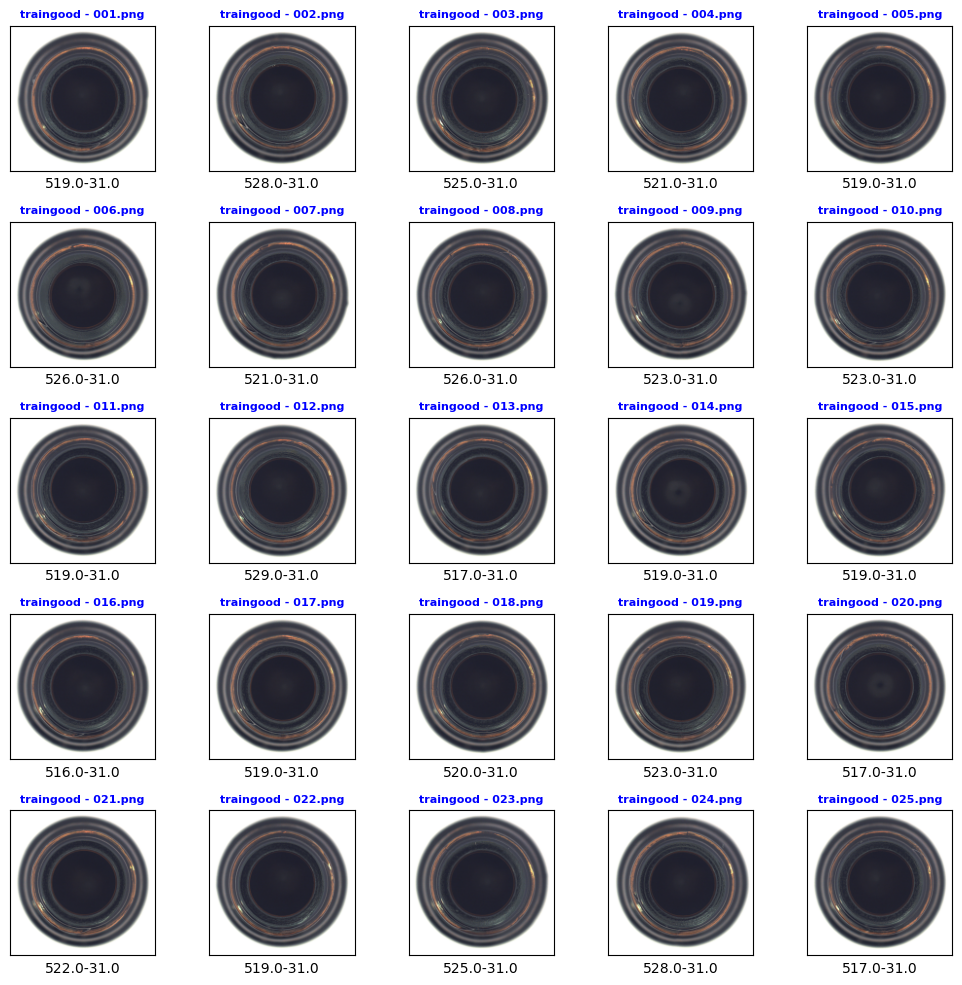

In [4]:
# TEST affichage des images
plt.figure(figsize=(10,10));

# Boucle sur un nombre d'images
nb_img=25
for j in range(1,nb_img+1):
    plt.subplot(5,5,j)
    plt.tight_layout()
    nom_fichier='traingood - '+format(j,"03d")+'.png'
    #conversion couleur de l'image pour affichage dans plt open cv utilise BGR et plt utilise RGB
    #choix des images
    img=images_dict[nom_fichier]['data']
    # Conversion
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Affichage
    plt.imshow(img)
    plt.title(nom_fichier,fontsize=8,fontweight='bold',color='blue')
    plt.xlabel(str(round(images_dict[nom_fichier]['taille initiale']/1024,0))+'-'+str(round(images_dict[nom_fichier]['taille resized']/1024,0)))
    plt.xticks([])
    plt.yticks([])
    plt.show;